# Diabetes Prediction: End-to-End Data Science Project
**Dataset:** Pima Indians Diabetes Database (768 patients, 8 clinical features)
**Goal:** predict whether a patient has diabetes (`Outcome` = 1) from routine measurements.

**Workflow:** 1. Data understanding → 2. Data cleaning → 3. EDA → 4. Preprocessing → 5. Model comparison → 6. Hyperparameter tuning → 7. Final evaluation → 8. Conclusions

## 1. Setup and data understanding

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance
import joblib

sns.set_theme(style="whitegrid")
SEED = 42

In [ ]:
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
        "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
try:
    df = pd.read_csv("diabetes.csv")
except FileNotFoundError:   # fallback: public copy of the same dataset
    df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv", names=cols)

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


| Feature | Meaning |
|---|---|
| Pregnancies | Number of pregnancies |
| Glucose | Plasma glucose (2h oral glucose test) |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skin fold thickness (mm) |
| Insulin | 2-hour serum insulin (µU/mL) |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Family-history score for diabetes |
| Age | Age in years |
| **Outcome** | **Target: 1 = diabetic, 0 = not diabetic** |

In [ ]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Data cleaning: hidden missing values
There are no `NaN`s, but a glucose, blood pressure, skin thickness, insulin or BMI of **0 is impossible**. These zeros are missing values, so we convert them to `NaN`.

Duplicate rows: 0


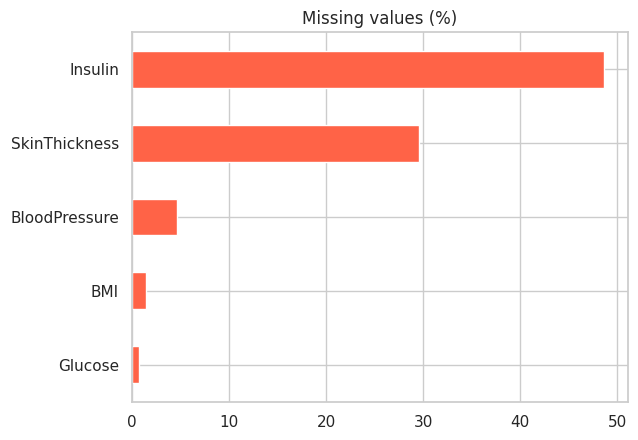

In [ ]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Duplicate rows:", df.duplicated().sum())

df[zero_cols] = df[zero_cols].replace(0, np.nan)
missing_pct = (df.isnull().mean() * 100).round(1)
missing_pct[missing_pct > 0].sort_values().plot.barh(color="tomato", title="Missing values (%)")
plt.show()

## 3. Exploratory data analysis

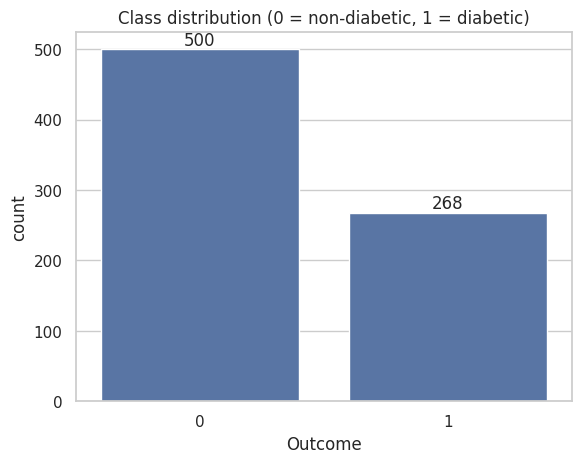

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [ ]:
ax = sns.countplot(x="Outcome", data=df)
ax.bar_label(ax.containers[0])
ax.set_title("Class distribution (0 = non-diabetic, 1 = diabetic)")
plt.show()
print(df["Outcome"].value_counts(normalize=True).round(3))

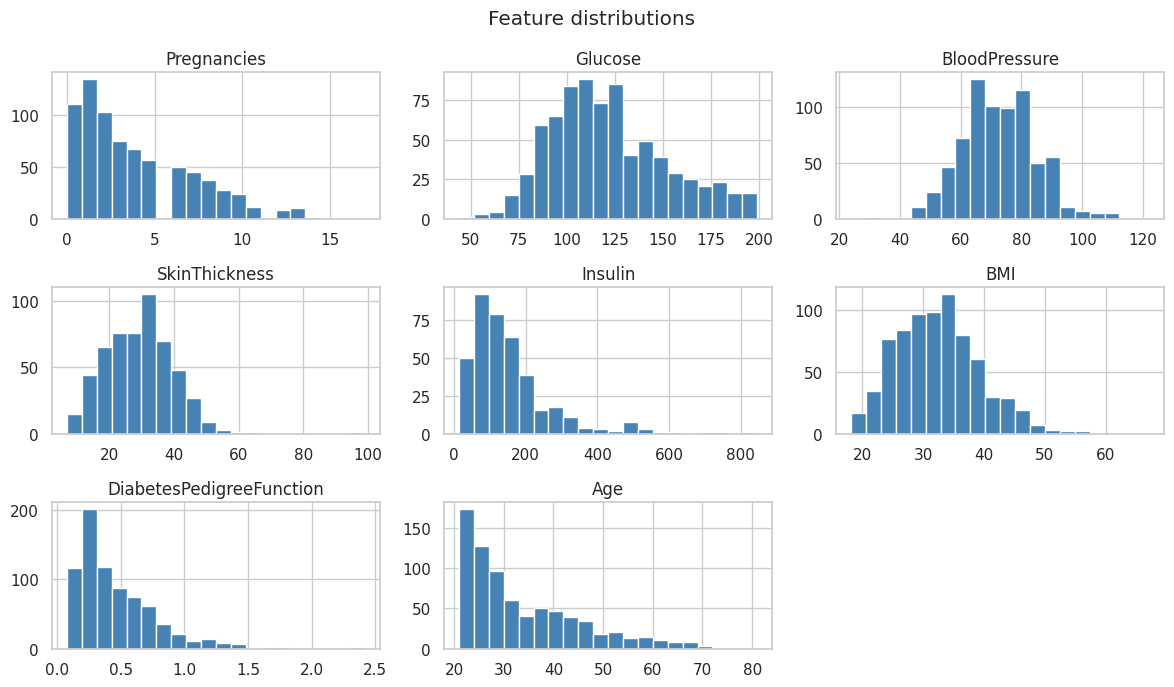

In [ ]:
df.drop(columns="Outcome").hist(bins=20, figsize=(12, 7), color="steelblue")
plt.suptitle("Feature distributions")
plt.tight_layout()
plt.show()

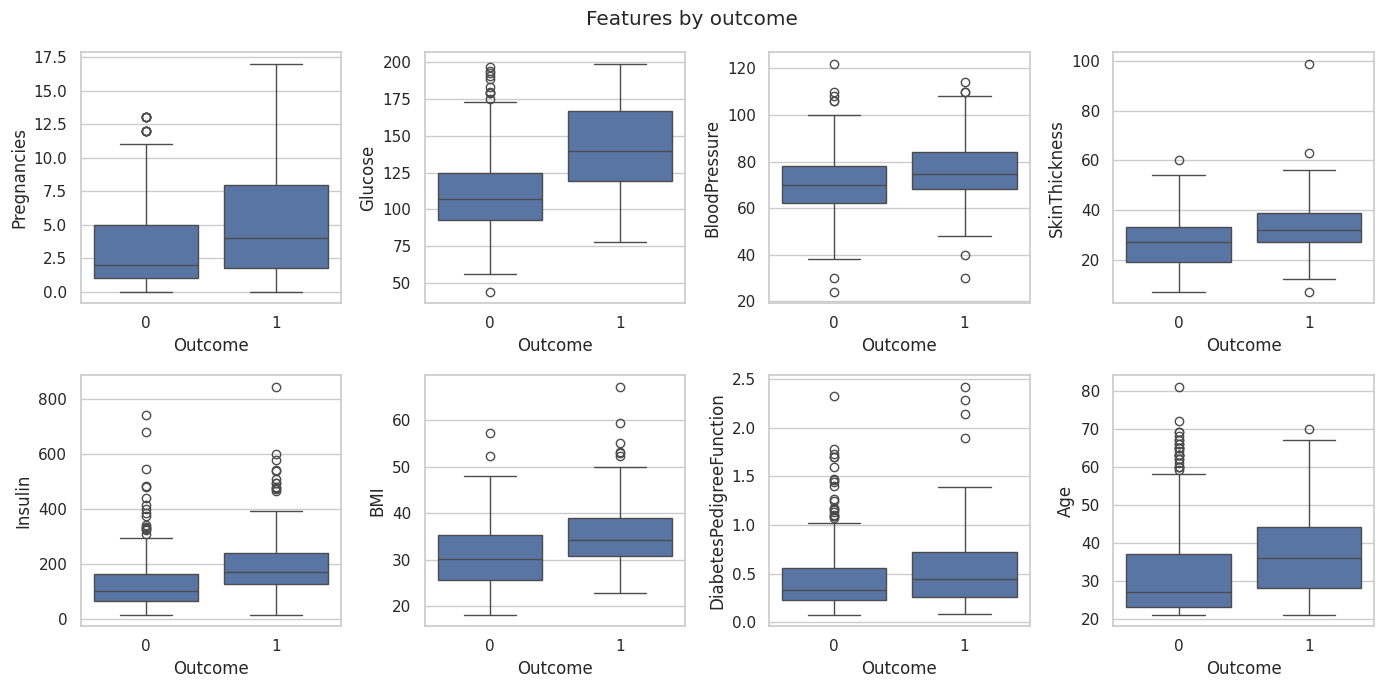

In [ ]:
features = df.columns.drop("Outcome")
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(x="Outcome", y=col, data=df, ax=ax)
plt.suptitle("Features by outcome")
plt.tight_layout()
plt.show()

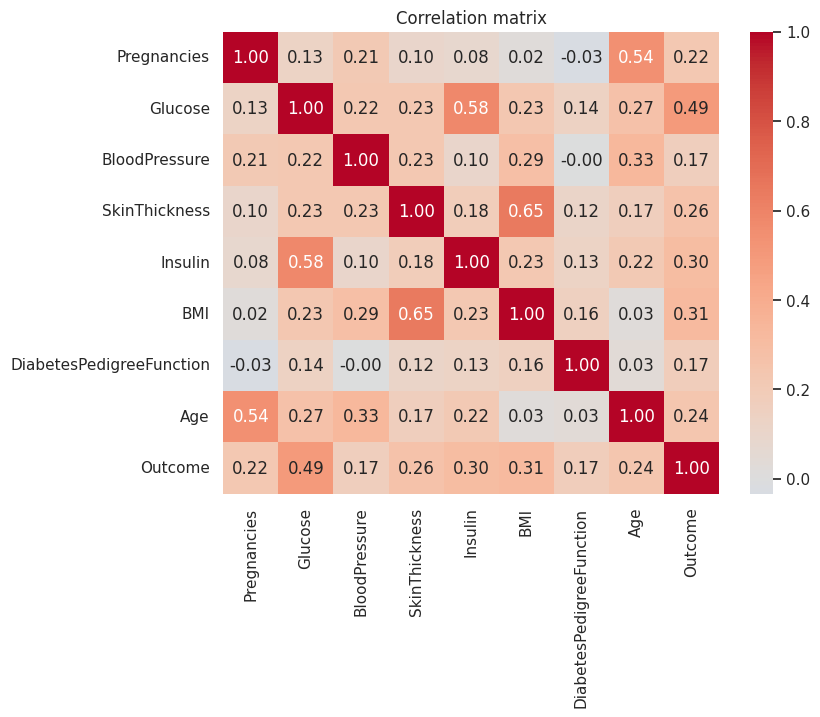

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

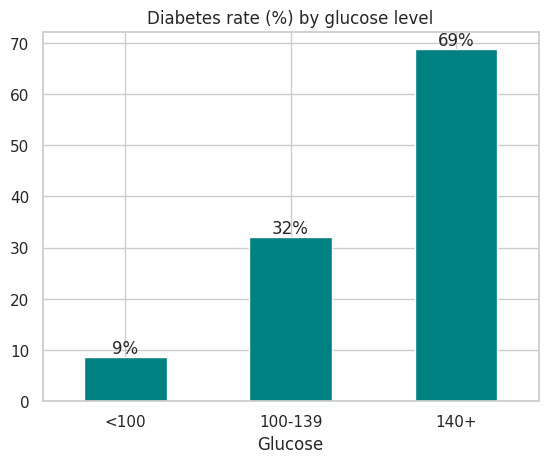

In [ ]:
# Diabetes rate by glucose band: a simple, clinically meaningful view
bands = pd.cut(df["Glucose"], [0, 100, 140, 300], labels=["<100", "100-139", "140+"])
rate = df.groupby(bands, observed=True)["Outcome"].mean() * 100
ax = rate.plot.bar(color="teal", rot=0, title="Diabetes rate (%) by glucose level")
ax.bar_label(ax.containers[0], fmt="%.0f%%")
plt.show()

### EDA takeaways
* **Missing values:** Insulin (49%) and SkinThickness (30%) are mostly missing; Glucose, BMI and BloodPressure have only a few. We impute rather than drop rows.
* **Class imbalance:** about 65% non-diabetic and 35% diabetic, so always predicting "non-diabetic" gives 65% accuracy. Accuracy alone is not enough; we use ROC-AUC and recall.
* **Glucose is the strongest signal:** correlation with the outcome is 0.49 (BMI 0.31, Insulin 0.30, Age 0.24). The diabetes rate rises from 9% (glucose under 100) to 32% (100-139) to 69% (140+).
* Boxplots show diabetic patients have higher glucose, BMI and age on average.

## 4. Preprocessing
We split the data **first** (80/20, stratified), then put imputation and scaling inside a `Pipeline`. This way the median values and scaling statistics are learned from training data only, which avoids data leakage (the original notebook scaled all the data before splitting).

In [ ]:
X = df.drop(columns="Outcome")
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Train:", X_train.shape, " Test:", X_test.shape)

def make_pipeline(model):
    return Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler", StandardScaler()),
                     ("model", model)])

Train: (614, 8)  Test: (154, 8)


## 5. Model comparison
Seven models, compared with 5-fold stratified cross-validation on the training set. We rank by **ROC-AUC** (works for imbalanced classes) and also report recall, because missing a diabetic patient is the costly mistake.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=SEED),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows = []
for name, model in models.items():
    s = cross_validate(make_pipeline(model), X_train, y_train, cv=cv,
                       scoring=["accuracy", "recall", "f1", "roc_auc"])
    rows.append({"Model": name, "Accuracy": s["test_accuracy"].mean(), "Recall": s["test_recall"].mean(),
                 "F1": s["test_f1"].mean(), "ROC-AUC": s["test_roc_auc"].mean()})

results = pd.DataFrame(rows).set_index("Model").sort_values("ROC-AUC", ascending=False)
results.round(3)

,Accuracy,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.788,0.575,0.655,0.843
SVM,0.780,0.584,0.648,0.833
Naive Bayes,0.762,0.598,0.637,0.828
Gradient Boosting,0.756,0.598,0.631,0.820
Random Forest,0.774,0.608,0.653,0.820
Decision Tree,0.735,0.547,0.589,0.790
KNN,0.730,0.565,0.594,0.784


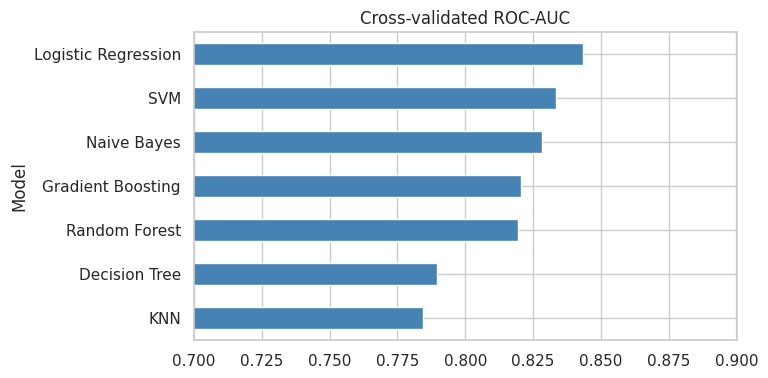

In [ ]:
results["ROC-AUC"].sort_values().plot.barh(color="steelblue", figsize=(7, 4), title="Cross-validated ROC-AUC")
plt.xlim(0.7, 0.9)
plt.show()

**Takeaways:** Logistic regression is best (AUC 0.843), followed by SVM (0.833). Simple models beat the decision tree and KNN, and the tree ensembles (AUC 0.820) did not win on this small dataset (614 training rows). Recall is only 0.55-0.61 for every model at the default 0.5 threshold, which we address in Section 7.

## 6. Hyperparameter tuning
We tune the best candidates with `GridSearchCV` (5-fold CV, scoring = ROC-AUC).

In [ ]:
param_grids = {
    "Logistic Regression": (LogisticRegression(max_iter=1000),
                            {"model__C": [0.01, 0.1, 1, 10]}),
    "SVM": (SVC(probability=True, random_state=SEED),
            {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1], "model__kernel": ["rbf", "linear"]}),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=SEED),
                      {"model__max_depth": [3, 5, 8], "model__min_samples_leaf": [3, 8, 15]}),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=SEED),
                          {"model__n_estimators": [50, 100, 200], "model__max_depth": [1, 2, 3],
                           "model__learning_rate": [0.03, 0.1]}),
}

tuned, rows = {}, []
for name, (model, grid) in param_grids.items():
    gs = GridSearchCV(make_pipeline(model), grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs.best_estimator_
    rows.append({"Model": name, "Default CV AUC": results.loc[name, "ROC-AUC"],
                 "Tuned CV AUC": gs.best_score_, "Best parameters": gs.best_params_})

tuning = pd.DataFrame(rows).set_index("Model").sort_values("Tuned CV AUC", ascending=False)
tuning

,Default CV AUC,Tuned CV AUC,Best parameters
Model,,,
SVM,0.833308,0.846307,"{'model__C': 1, 'model__gamma': 0.01, 'model__..."
Logistic Regression,0.843364,0.844387,{'model__C': 0.1}
Random Forest,0.819507,0.840642,"{'model__max_depth': 5, 'model__min_samples_le..."
Gradient Boosting,0.820446,0.834257,"{'model__learning_rate': 0.1, 'model__max_dept..."


**Takeaways:** Tuning helps the SVM (0.833 → 0.846) and random forest (0.820 → 0.841) but barely changes logistic regression (0.843 → 0.844). The top three models are within about 0.006 AUC, so the choice between them is close to a tie. The SVM is selected because it has the highest cross-validated score.

## 7. Final evaluation on the test set
The model with the best cross-validated AUC is selected, then scored **once** on the untouched test set.

In [ ]:
best_name = tuning.index[0]
best_model = tuned[best_name]          # already fitted on the training set
print("Selected model:", best_name)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Non-diabetic", "Diabetic"]))

Selected model: SVM
Accuracy : 0.708
Precision: 0.610
Recall   : 0.463
F1 score : 0.526
ROC-AUC  : 0.805

              precision    recall  f1-score   support

Non-diabetic       0.74      0.84      0.79       100
    Diabetic       0.61      0.46      0.53        54

    accuracy                           0.71       154
   macro avg       0.68      0.65      0.66       154
weighted avg       0.70      0.71      0.70       154



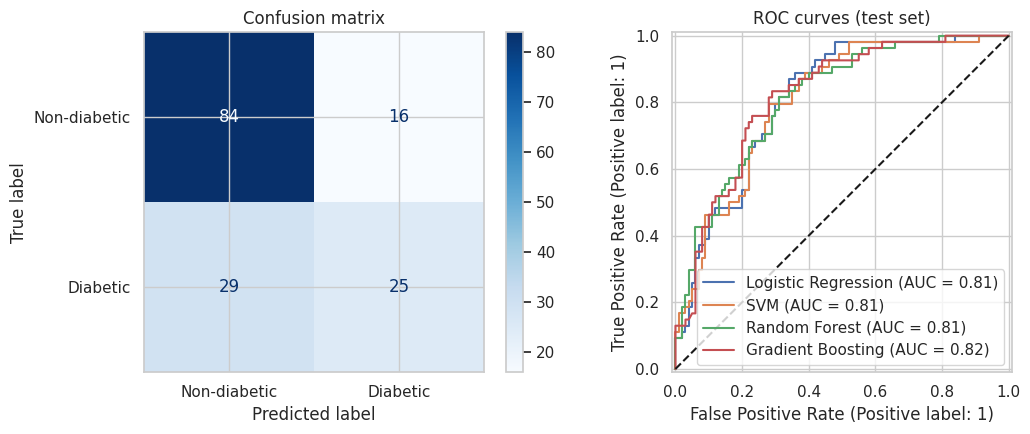

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Non-diabetic", "Diabetic"],
                                        cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix")

for name, model in tuned.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC curves (test set)")

plt.tight_layout()
plt.show()

### Feature importance
Permutation importance shuffles one feature at a time and measures how much the AUC drops. It works for any model.

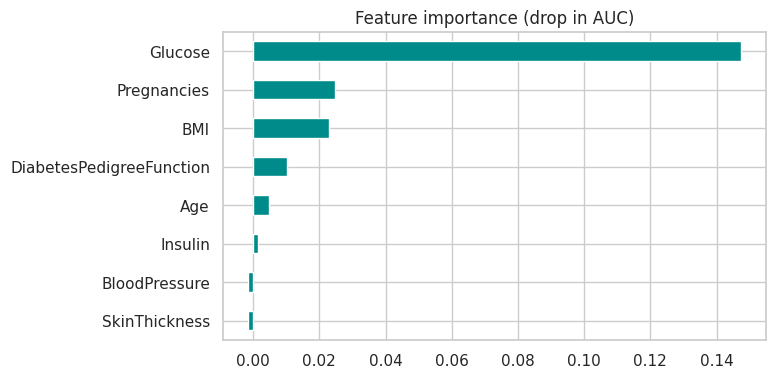

In [ ]:
imp = permutation_importance(best_model, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=SEED)
pd.Series(imp.importances_mean, index=X.columns).sort_values().plot.barh(color="darkcyan", figsize=(7, 4),
                                                                      title="Feature importance (drop in AUC)")
plt.show()

### Adjusting the decision threshold
The default cut-off of 0.5 misses many diabetic patients. For screening we want high recall, so we choose the **highest threshold that still gives at least 80% recall on the training data** (using cross-validated predictions), then apply it to the test set.

In [ ]:
oof_prob = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

thresholds = np.arange(0.2, 0.71, 0.05)
table = pd.DataFrame({"Threshold": thresholds,
                      "Precision": [precision_score(y_train, oof_prob >= t) for t in thresholds],
                      "Recall": [recall_score(y_train, oof_prob >= t) for t in thresholds]}).round(3)
display(table.set_index("Threshold").T)

THRESHOLD = table.loc[table["Recall"] >= 0.80, "Threshold"].max()
print("Chosen threshold:", round(THRESHOLD, 2))

Threshold,0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70
Precision,0.528,0.557,0.620,0.654,0.687,0.724,0.747,0.764,0.789,0.811,0.827
Recall,0.893,0.818,0.762,0.715,0.678,0.626,0.593,0.528,0.491,0.463,0.379


Chosen threshold: 0.25


In [ ]:
y_pred_thr = (y_prob >= THRESHOLD).astype(int)
compare = pd.DataFrame({
    "Threshold 0.50": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred)],
    f"Threshold {THRESHOLD:.2f}": [accuracy_score(y_test, y_pred_thr), precision_score(y_test, y_pred_thr), recall_score(y_test, y_pred_thr)],
}, index=["Accuracy", "Precision", "Recall"]).round(3)
compare

,Threshold 0.50,Threshold 0.25
Accuracy,0.708,0.701
Precision,0.610,0.549
Recall,0.463,0.833


**Takeaways**
* The SVM scores **ROC-AUC 0.805** on the test set (training CV was 0.846, so the test result is a bit lower; with only 154 test patients, expect noise of a few points).
* At the default 0.5 cut-off, recall is only **46%**: more than half of the diabetic patients are missed.
* Lowering the threshold to 0.25 (chosen from training data only) raises recall to **83%**, at the cost of precision (61% → 55%) and slightly lower accuracy (70.8% → 70.1%). For screening this is the better trade-off.
* Feature importance: **Glucose dominates** (AUC drops by about 0.15 when shuffled), followed by Pregnancies and BMI. SkinThickness, BloodPressure and Insulin add almost nothing, partly because they are so often missing.

## 8. Save the model and make predictions

In [ ]:
joblib.dump({"model": best_model, "threshold": THRESHOLD}, "diabetes_model.joblib")

def predict(patient):
    """patient: dict with the 8 features. Use 0 or NaN for unmeasured Glucose/BP/Skin/Insulin/BMI."""
    row = pd.DataFrame([patient])[list(X.columns)].replace({c: {0: np.nan} for c in zero_cols})
    p = best_model.predict_proba(row)[0, 1]
    return f"Probability of diabetes: {p:.2f} -> {'Diabetic (high risk)' if p >= THRESHOLD else 'Not diabetic (low risk)'}"

print(predict({"Pregnancies": 7, "Glucose": 187, "BloodPressure": 68, "SkinThickness": 39,
               "Insulin": 304, "BMI": 37.7, "DiabetesPedigreeFunction": 0.254, "Age": 41}))

Probability of diabetes: 0.93 -> Diabetic (high risk)


## 9. Conclusions
* **Result:** an SVM pipeline reaches a test ROC-AUC of about **0.81**. With a recall-oriented threshold of 0.25 it catches about **83%** of diabetic patients, with roughly 55% precision.
* **Main lessons:** (1) zeros in medical columns are missing values; (2) splitting before preprocessing avoids leakage; (3) simple models (logistic regression, SVM) performed as well as or better than tree ensembles here; (4) the threshold matters more than the model for a screening use case.
* **Limitations:** only 768 patients from one population, so results are uncertain (the test set has just 154 patients) and may not generalise. This is a learning project, not a diagnostic tool.
* **Next steps:** try nested cross-validation, probability calibration, SHAP explanations, and a Streamlit app for the saved model.